# Notebook 02 — Stage O: LP Dispatch Optimisation (R3)

This notebook implements **Stage O** of the pipeline:

1. Load `lambda_factor` (from Stage M) and the network distance matrix
2. Solve the **Static-LP** once for the full 24-hour horizon → `x_sol_static`
3. Save `lp_assignment_static.json` for the Static-LP simulation arm

The MPC arm does NOT pre-solve here — it re-solves a 6-hour rolling window
at each replan boundary in Stage S, using the actual current bank inventory.

**Prerequisite:** `notebook_01_forecasting.ipynb`.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.utils.config_loader import load_config
from src.utils.distance import load_distance_matrix, flight_time_matrix
from src.optimization.lp_formulation import LPDispatchSolver

print("Imports successful")

Imports successful


## 1. Load inputs

In [2]:
network_cfg = load_config(repo_root / "config" / "network.yaml")
lp_cfg      = load_config(repo_root / "config" / "lp.yaml")
sim_cfg     = load_config(repo_root / "config" / "simulation.yaml")

processed = repo_root / "data" / "processed"

# Factor planning rates from Stage M
lambda_factor = pd.read_csv(processed / "lambda_factor.csv", index_col=0).values  # (12, 24)

# Distance matrix → flight times
d_km      = load_distance_matrix(network_cfg)
speed_kmh = float(sim_cfg["drone"]["speed_kmh"])
d_min     = flight_time_matrix(d_km, speed_kmh)

# Initial inventory: 50 units * 4 types per bank
init_per_type = int(sim_cfg["inventory"]["initial_per_bank_per_type"])
n_types       = len(sim_cfg["inventory"]["blood_types"])
I_init        = np.full(3, float(init_per_type * n_types))

print(f"lambda_factor: shape={lambda_factor.shape}  mean={lambda_factor.mean():.3f}")
print(f"d_km shape:    {d_km.shape}")
print(f"I_init:        {I_init}")
print(f"C_fleet:       {lp_cfg['fleet']['C_fleet']}")

lambda_factor: shape=(12, 24)  mean=1.084
d_km shape:    (3, 12)
I_init:        [200. 200. 200.]
C_fleet:       32


## 2. Solve the Static-LP

In [3]:
solver = LPDispatchSolver(lp_cfg)
x_sol_static = solver.solve(lambda_factor, d_min, I_init)

T, B, H = 24, 3, 12
total_assigned = sum(max(0, x_sol_static.get((b, h, t), 0))
                     for b in range(B) for h in range(H) for t in range(T))
inventory_cap  = B * init_per_type * n_types / float(lp_cfg.get("avg_units_per_delivery", 2.5))
print(f"Total deliveries planned: {total_assigned}")
print(f"Inventory ceiling (no replenishment): {inventory_cap:.0f}")
print(f"Utilisation: {total_assigned / inventory_cap:.1%}")

14:37:32 [INFO] src.optimization.lp_formulation: Multi-period LP status=Optimal | total unmet demand (slack)=222.0
Total deliveries planned: 240
Inventory ceiling (no replenishment): 240
Utilisation: 100.0%


## 3. Inspect — assignment matrix at peak hour t=14

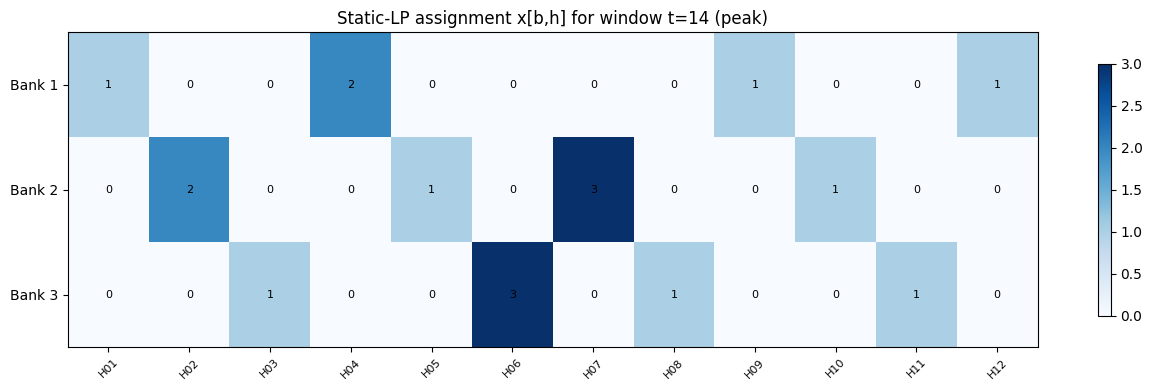

In [4]:
t_show = 14
mat = np.array([[max(0, x_sol_static.get((b, h, t_show), 0)) for h in range(H)]
                for b in range(B)], dtype=float)

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(mat, aspect="auto", cmap="Blues", vmin=0)
ax.set_xticks(range(H))
ax.set_xticklabels([f"H{h+1:02d}" for h in range(H)], rotation=45, fontsize=8)
ax.set_yticks(range(B))
ax.set_yticklabels([f"Bank {b+1}" for b in range(B)])
for b in range(B):
    for h in range(H):
        ax.text(h, b, f"{mat[b,h]:.0f}", ha="center", va="center", fontsize=8)
ax.set_title(f"Static-LP assignment x[b,h] for window t={t_show} (peak)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Window-by-window total assignments

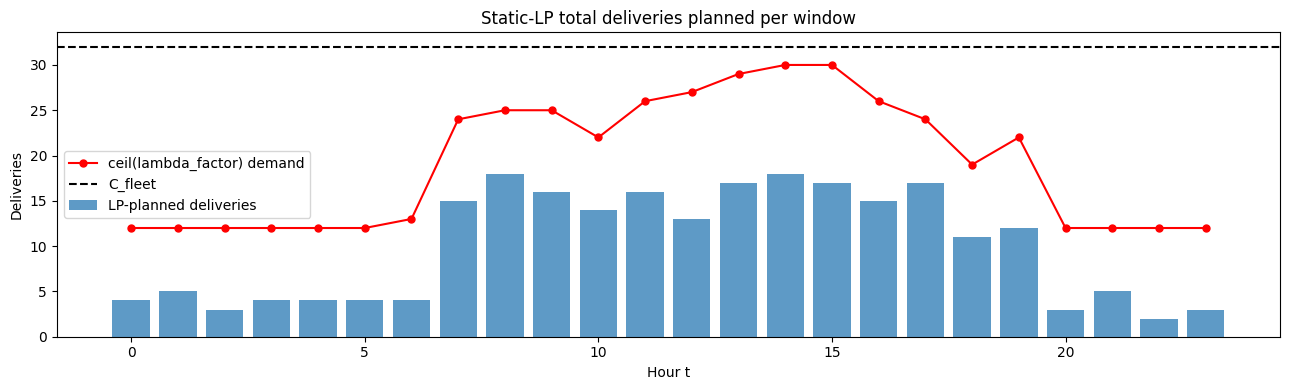

In [5]:
totals = [
    sum(max(0, x_sol_static.get((b, h, t), 0)) for b in range(B) for h in range(H))
    for t in range(T)
]
demand = [int(np.ceil(lambda_factor[:, t]).sum()) for t in range(T)]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(T), totals, alpha=0.7, color="#1a6faf", label="LP-planned deliveries")
ax.plot(range(T), demand, "ro-", lw=1.5, ms=5, label="ceil(lambda_factor) demand")
ax.axhline(lp_cfg["fleet"]["C_fleet"], color="black", ls="--", label="C_fleet")
ax.set_xlabel("Hour t")
ax.set_ylabel("Deliveries")
ax.set_title("Static-LP total deliveries planned per window")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Save x_sol_static

In [6]:
out_path = processed / "lp_assignment_static.json"
solver.save(out_path)
print(f"Static-LP plan saved to {out_path}")

# Verify reload
loaded = LPDispatchSolver.load(out_path)
print(f"Reloaded {len(loaded)} entries OK")

14:37:32 [INFO] src.optimization.lp_formulation: LP assignment saved to C:\Users\mhamm\Downloads\New_Project\mso_blood_delivery\data\processed\lp_assignment_static.json
Static-LP plan saved to C:\Users\mhamm\Downloads\New_Project\mso_blood_delivery\data\processed\lp_assignment_static.json
Reloaded 864 entries OK


## Stage O Complete

**Output:**
- `data/processed/lp_assignment_static.json` ← Static-LP plan for Stage S

The MPC arm self-solves at simulation runtime; no static plan is needed for it.

**Next:** Run `notebook_03_simulation.ipynb`.